In [165]:
from src import *
from myutils import *
from scipy.special import erf, erfc

In [237]:
sigma = DI.SIGMA / qCMOS.PIXEL_SIZE
A = 5 * DMD.PIXEL_SIZE / qCMOS.PIXEL_SIZE / 2
A = 0.01*sigma
N = 10
A, sigma

(0.2239130434782609, 22.39130434782609)

In [238]:
def spade_p(k, s):
    xi = s / (2*sigma)
    return 1/2 * (xi+k)**2 * np.exp(-xi**2)

def spade_dv_p(k, s):
    xi = s / (2*sigma)
    return - 1/(2*sigma) * (xi+k) * (xi**2+k*xi-1) * np.exp(-xi**2)

def spade_eta(s, I0, b):
    uk = lambda k: I0 * spade_p(k, s) + b
    dv_uk = lambda k: I0 * spade_dv_p(k, s)
    return np.array([1/uk(k) * dv_uk(k)**2 for k in (-1, 1)]).sum(0)

def spade_func_s(n, freq):
    return A * np.sin(tau * freq * n)

def spade_fi(freq, I0, b):
    return np.array([spade_eta(spade_func_s(n, freq), I0, b) * (A*tau*n*np.cos(tau*freq*n))**2 for n in range(N)]).sum(0)



In [239]:
def di_p(k, s):
    z1 = (k - s + 0.5) / (sigma * (2**0.5))
    z2 = (k - s - 0.5) / (sigma * (2**0.5))
    return erf(z1)/2 - erf(z2)/2

def di_dv_p(k, s):
    z1 = (k - s + 0.5) / (sigma * (2**0.5))
    z2 = (k - s - 0.5) / (sigma * (2**0.5))
    return 1/(sigma*(tau**0.5)) * (-np.exp(-z1**2) + np.exp(-z2**2))

def di_eta(s, I0, b):
    uk = lambda k: I0 * di_p(k, s) + b
    dv_uk = lambda k: I0 * di_dv_p(k, s)
    return np.array([1/uk(k) * (dv_uk(k)**2) for k in np.arange(-100, 100)]).sum(0)

def di_func_s(n, freq):
    return A * np.sin(tau * freq * n)

def di_fi(freq, I0, b):
    return np.array([di_eta(di_func_s(n, freq), I0, b) * (A*tau*n*np.cos(tau*freq*n))**2 for n in range(N)]).sum(0)



In [35]:
di_x, spade_x = [], []
di_y, spade_y = [], []

spade_pn, di_pn = [LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d0.npz').photons.mean() for m in ('spade', 'di')]

for duty in np.arange(0, 101, 2):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(qCMOS.convert2photons(c.background.mean()))
            spade_y.append(c.estimates_a.var(ddof=1) * spade_pn)

        if m == 'di':
            di_x.append(qCMOS.convert2photons(c.background.mean()))
            di_y.append(c.estimates_a.var(ddof=1) * di_pn)

In [191]:
spade_pn, di_pn

(67.58407700000001, 425.831021)

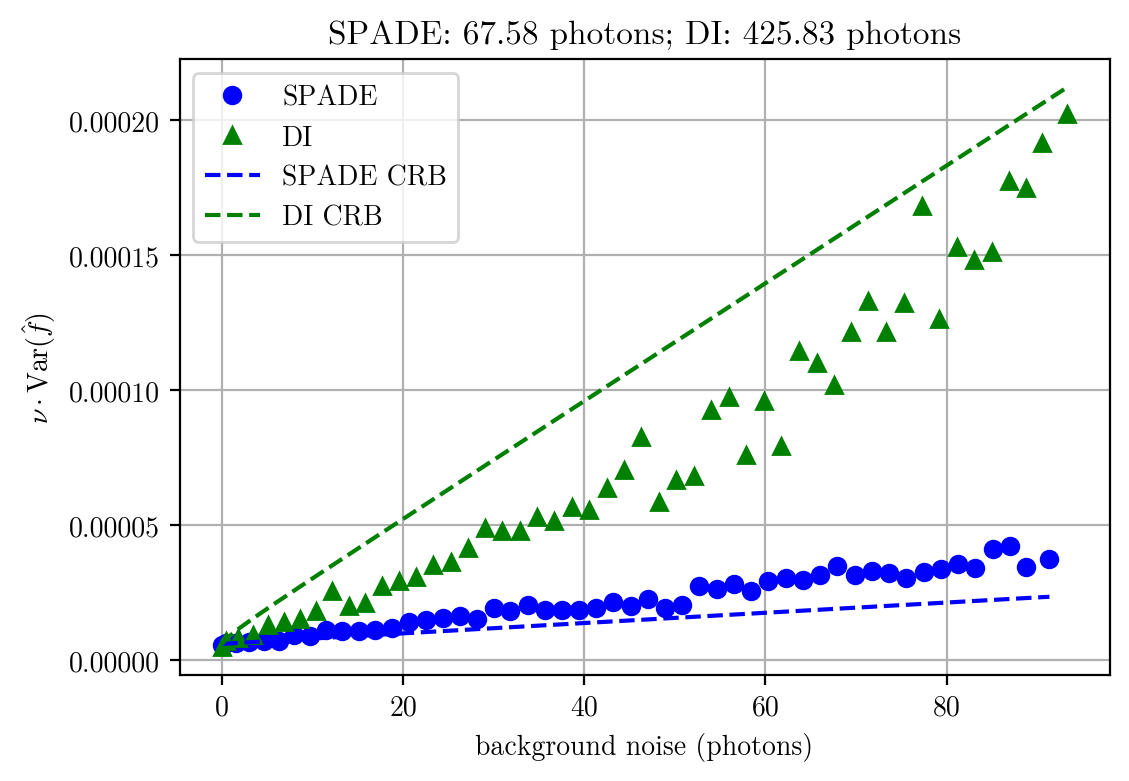

In [215]:
plot(spade_x, spade_y, 'o', label='SPADE', title='SPADE: 67.58 photons; DI: 425.83 photons')
plot(di_x, di_y, '^', label='DI', xlabel=r'background noise (photons)', ylabel=r'$\nu\cdot{\rm Var}(\hat f)$')

plot(spade_x, 1 / spade_fi(0.2, 1, spade_x/spade_pn), 'b--', label='SPADE CRB')
plot(di_x, 1 / di_fi(0.2, 1, di_x/di_pn), 'g--', label='DI CRB')

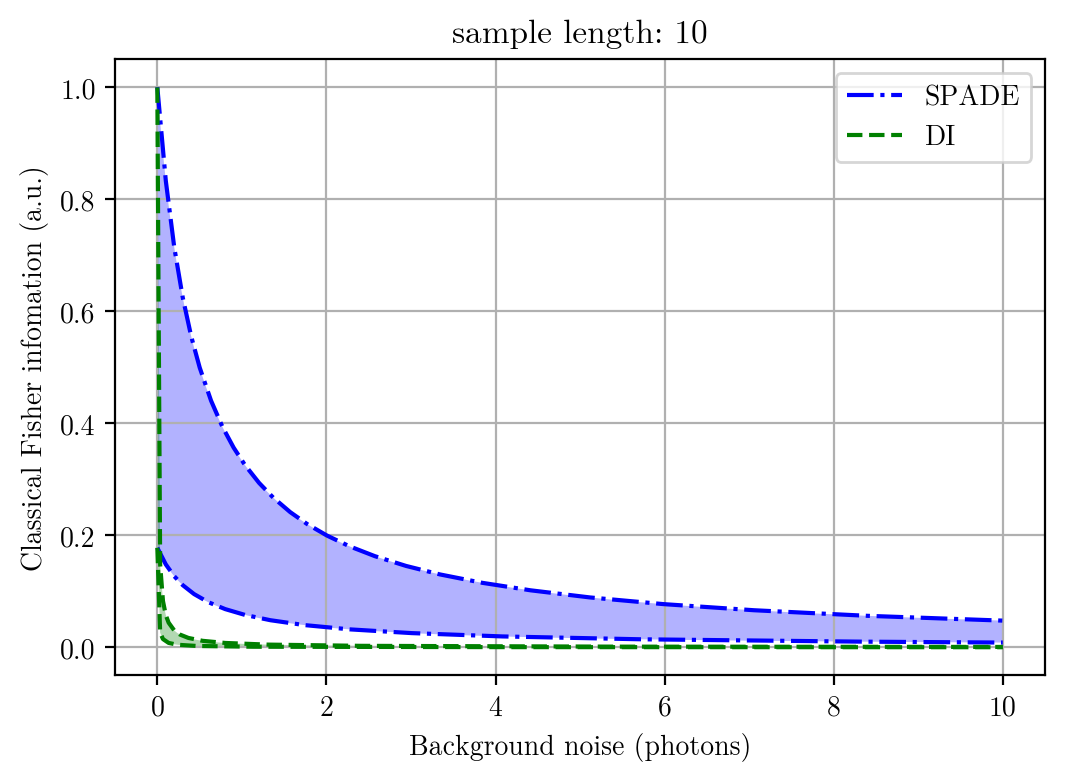

In [315]:

max = spade_fi(0.06253, 1, 0)
x = np.linspace(0, 10, 300)
plot(x, spade_fi(0.06253, 1, x) / max, 'b-.', title='sample length: 10')
plot(x, spade_fi(0.03253, 1, x) / max, 'b-.', label='SPADE')

plot(x, di_fi(0.06253, 1, x) / max, 'g--', ylabel='Classical Fisher infomation (a.u.)', xlabel='Background noise (photons)')
plot(x, di_fi(0.03253, 1, x) / max, 'g--', label='DI')

plt.fill_between(x, spade_fi(0.06253, 1, x) / max, spade_fi(0.03253, 1, x) / max, alpha=0.3)
plt.fill_between(x, di_fi(0.06253, 1, x) / max, di_fi(0.03253, 1, x) / max, alpha=0.3)
plt.savefig('1.svg')
plt.show()

In [297]:
[0.06253, 0.03253]

0.06253

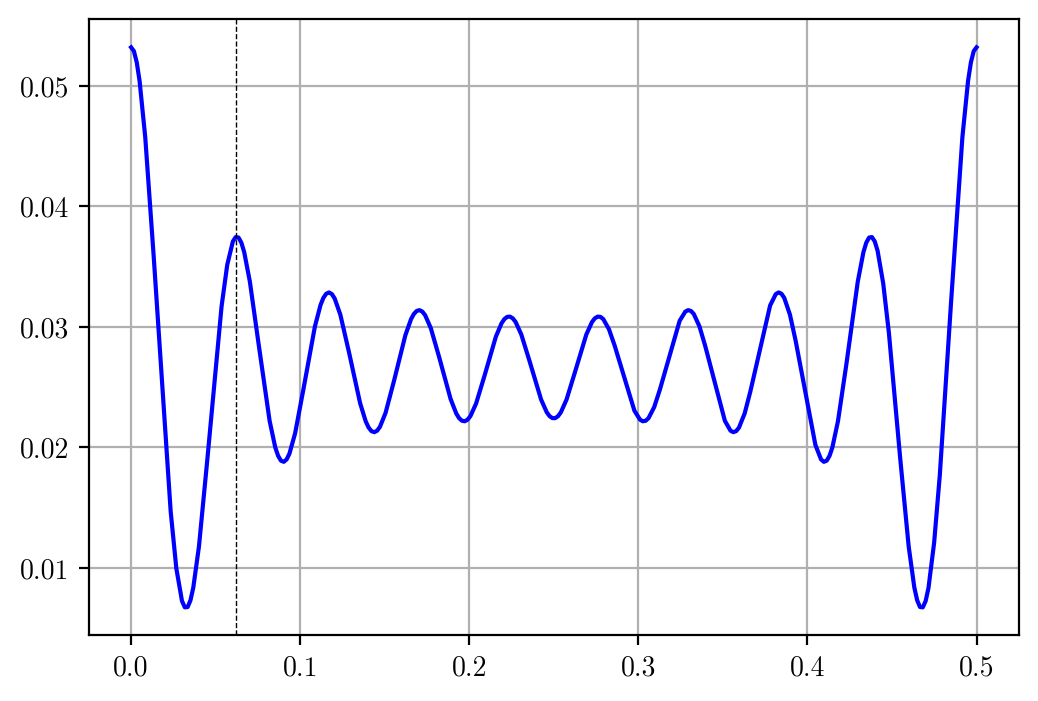

In [295]:
plot((0, 0.5), lambda f: FisherInformation([0.01*sigma], f, N=10)[0])
axline(v=0.062)

In [2]:
def p_spade(q, theta):
    return 1/8 * np.exp(-theta**2 / (4*sigma**2)) * (q * 2 + theta/sigma)**2

def part_p_spade(q, theta):
    return 1/(16*sigma**4) * np.exp(-theta**2 / (4*sigma**2)) * (-theta**3 + (-1)**(q+1)*4*theta**2*sigma + (-1)**q*8*sigma**3)

def fi_spade(theta, I0, b):
    uk = lambda q: I0 * p_spade(q, theta, sigma) + b
    part_uk = lambda q: I0 * part_p_spade(q, theta, sigma)
    return 1/uk(0) * part_uk(0)**2 + 1/uk(1) * part_uk(1)**2

In [18]:
def p_di(x, theta, sigma=100):
    z1 = (x - theta + 0.5) / (sigma * (2**0.5))
    z2 = (x - theta - 0.5) / (sigma * (2**0.5))
    return erf(z1)/2 - erf(z2)/2

def part_p_di(x, theta, sigma=100):
    z1 = (x - theta + 0.5) / (sigma * (2**0.5))
    z2 = (x - theta - 0.5) / (sigma * (2**0.5))
    return 1/(sigma*tau**0.5) * (-np.exp(-z1**2) + np.exp(-z2**2))


def fi_di(theta, I0, b, sigma=100):
    uk = lambda x: I0 * p_di(x, theta, sigma) + b
    part_uk = lambda x: I0 * part_p_di(x, theta, sigma)
    x = np.arange(-4*sigma, 4*sigma)
    return np.sum(1/uk(x) * part_uk(x)**2)


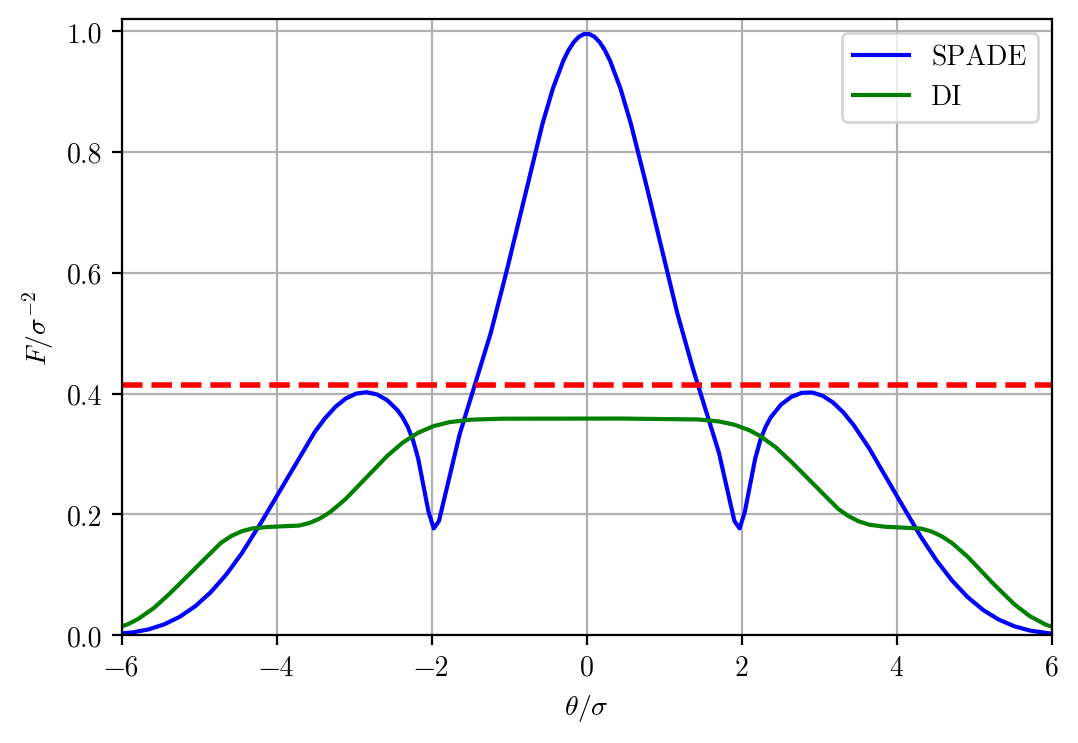

In [22]:
theta_range = np.linspace(-1000, 1000, 300)

b = 1
pn = 500

ss = 1 / ((100**2 + 1/12)/pn + (4 * pi**0.5 * 100**3 * b**2)/(pn**2))

plot(theta_range / 100, lambda theta: fi_spade(theta * 100, pn, b) * 100**2 / pn, label='SPADE', xlim=(-6, 6), ylim=(0, 1.02), title='')
plot(theta_range / 100, lambda theta: fi_di(theta * 100, pn, b) * 100**2 / pn, label='DI', xlabel=r'$\theta/\sigma$', ylabel=r'$F/{\sigma^{-2}}$')
axline(h=ss * 100**2 / pn, w=2, c='r')

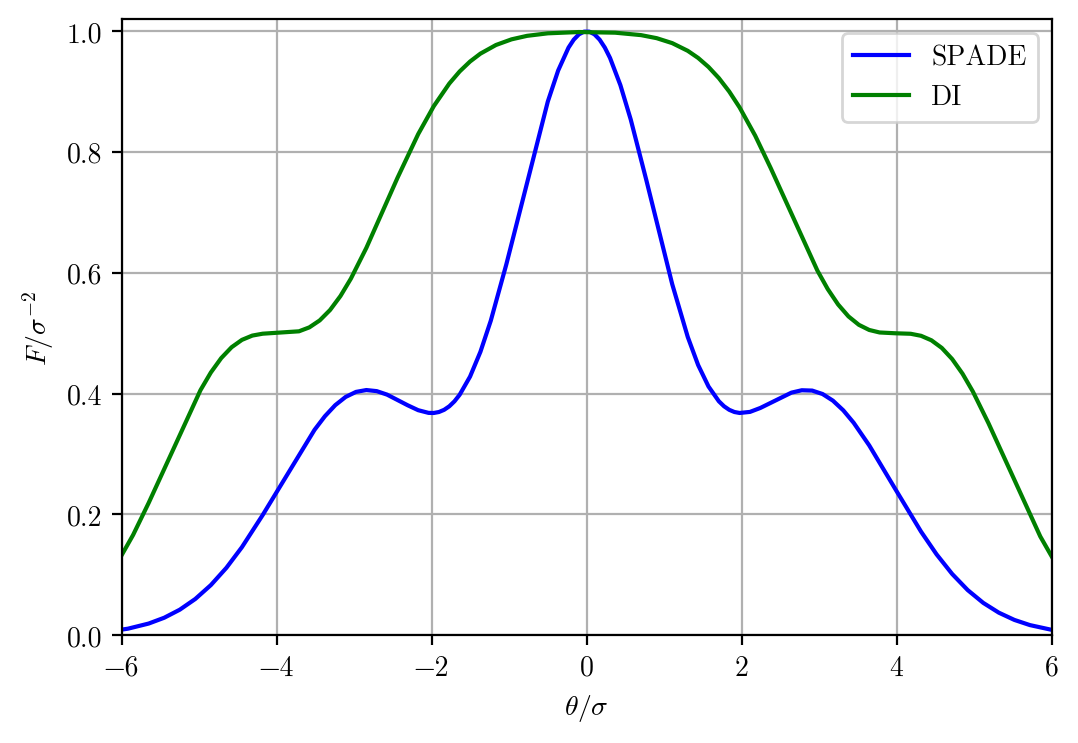

In [12]:
theta_range = np.linspace(-1000, 1000, 300)

plot(theta_range / 100, lambda theta: fi_spade(theta * 100, 1, 1e-10) * 100**2, label='SPADE', xlim=(-6, 6), ylim=(0, 1.02))
plot(theta_range / 100, lambda theta: fi_di(theta * 100, 1, 1e-10) * 100**2, label='DI', xlabel=r'$\theta/\sigma$', ylabel=r'$F/{\sigma^{-2}}$')

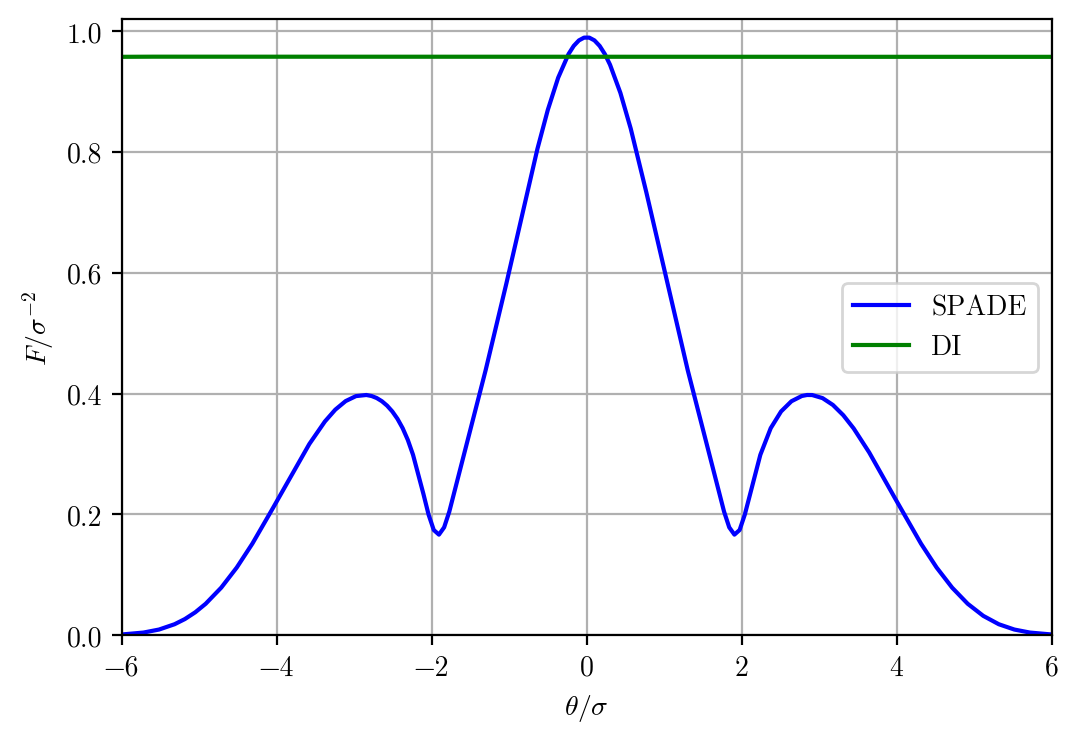

In [ ]:
theta_range = np.linspace(-1000, 1000, 300)

snr = 100 

plot(theta_range / 100, lambda theta: fi_spade(theta * 100, 100, (100/2)/snr ) * 100, label='SPADE', xlim=(-6, 6), ylim=(0, 1.02), title='')
plot(theta_range / 100, lambda theta: fi_di(theta * 100, 100, (100/600)/snr ) * 100, label='DI', xlabel=r'$\theta/\sigma$', ylabel=r'$F/{\sigma^{-2}}$')

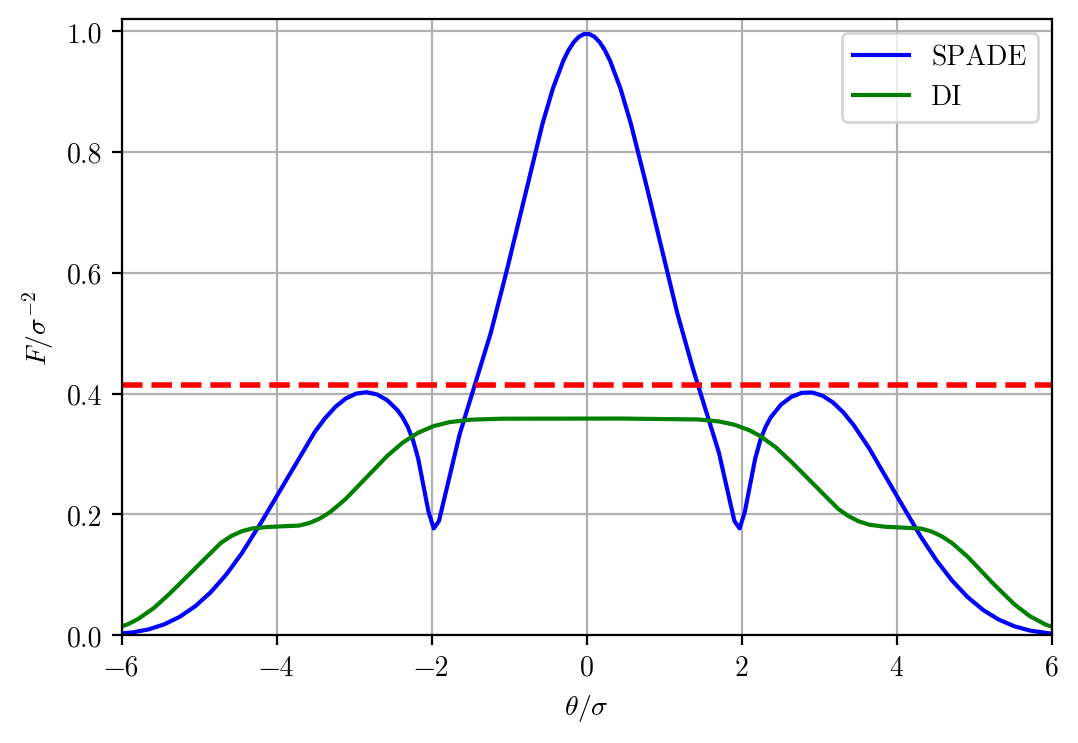

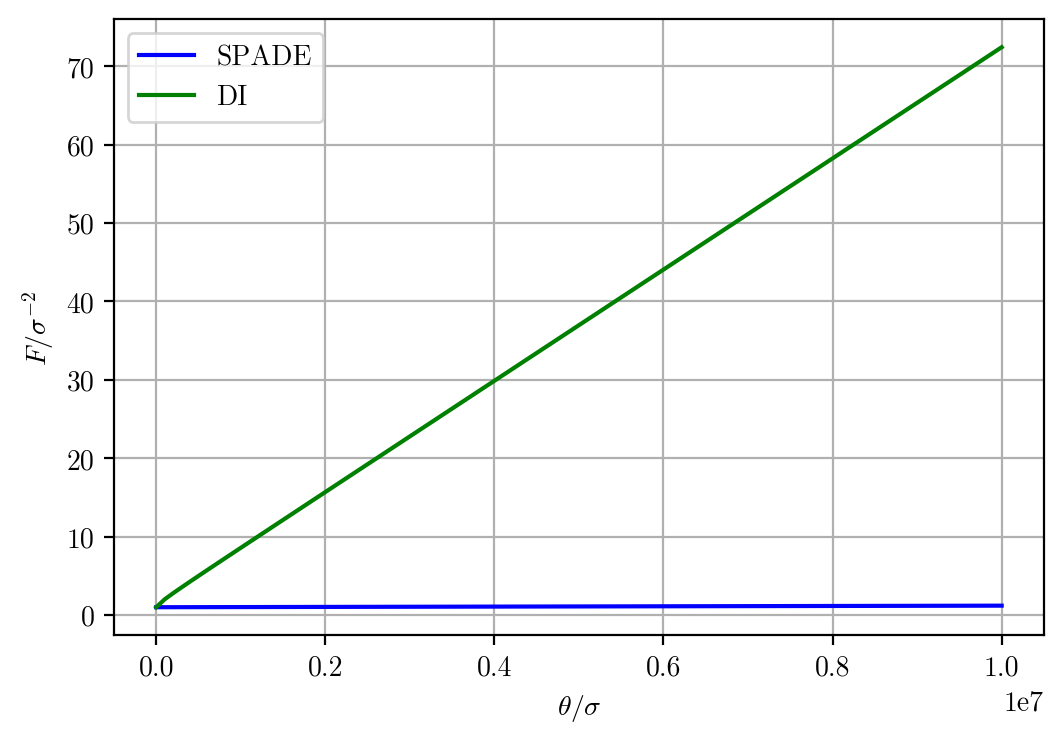

In [175]:
b = np.linspace(1e-10, 1e7, 100)
pn = 1e8


plot(b, lambda bb: 1/(fi_spade(0, pn, bb) * 100**2 / pn), label='SPADE', title='')
plot(b, lambda bb: 1/(fi_di(0, pn, bb) * 100**2 / pn), label='DI', xlabel=r'$\theta/\sigma$', ylabel=r'$F/{\sigma^{-2}}$')

实验最高 background noise 89 个光子